# LSM Index (Log-Structured Merge Tree)

Designed for **write-heavy** workloads. Instead of updating data in-place on disk, all writes go to an **in-memory buffer (MemTable)** first, then are flushed sequentially to disk as immutable **SSTables (Sorted String Tables)**.

**Used by:** Cassandra, RocksDB, LevelDB, HBase, ScyllaDB

## How LSM Tree Writes Work (Step by Step)

### Step 1 — Write hits the MemTable (in-memory)

```
INSERT INTO events (id, data) VALUES (1, 'click');
```

- Goes into the **MemTable** — an in-memory sorted buffer (e.g., a Red-Black tree).
- No disk I/O. Extremely fast.
- Also written to a **Write-Ahead Log (WAL)** for crash recovery.

---

### Step 2 — MemTable fills up → Flushed to SSTable on disk

```
MemTable (RAM, ~64MB full)
    ↓ flush
L0/SSTable-1.sst  (immutable, sorted file on disk)
```

- SSTables are **sorted** and **immutable** — never modified after written.
- Multiple SSTables can accumulate at Level 0 (L0).

---

### Step 3 — SSTables pile up at L0

```
L0: [SSTable-1] [SSTable-2] [SSTable-3] [SSTable-4]
```

- These files can have **overlapping key ranges**.
- Reads get slower as more SSTables exist (must check each one).

---

### Step 4 — Compaction merges SSTables

The database merges overlapping SSTables to reclaim space and improve read performance:

1. **Read** all SSTables involved
2. **Sort + merge** them (keep only the latest version of each key)
3. **Write** the merged result as a new SSTable to the next level
4. **Delete** the old SSTables

```
L0: [1,5,9] + [2,5,8] + [3,6,7]   <- read all 3
         |  merge + sort
         v
L1: [1,2,3,5,6,7,8,9]              <- write new merged file
         |
         v  delete originals
```

## Write Amplification During Compaction

**Write amplification** means: for every **1 byte you logically write**, the database physically writes **N bytes to disk** due to repeated merging across levels.

### Concrete Example

Say you update the same key 5 times:

```
UPDATE user SET status='active'    -> SSTable-1
UPDATE user SET status='inactive'  -> SSTable-2
UPDATE user SET status='active'    -> SSTable-3
UPDATE user SET status='inactive'  -> SSTable-4
UPDATE user SET status='active'    -> SSTable-5
```

LSM does **not** overwrite — it appends each version as a new entry. All 5 versions live on disk across different SSTables.

During compaction: reads all 5, discards 4 stale versions, writes 1 final result.

```
Net result: 1 logical write -> 5 disk writes + 1 merge write = ~6x amplification
```

### The Multi-Level Cascade (Why It Gets Worse)

LSM uses multiple levels, each 10x larger than the previous:

```
L0  (~4 SSTables,    ~256MB)
L1  (~10 SSTables,   ~2.5GB)
L2  (~100 SSTables,  ~25GB)
L3  (~1000 SSTables, ~250GB)
```

- L0 fills up → compacted into L1
- L1 fills up → compacted into L2
- L2 fills up → compacted into L3

A single row written at L0 may get **rewritten at every level** before it settles.  
Real-world write amplification for RocksDB/Cassandra: **10x – 30x**.

## Read Path (Why Reads Are Slower)

To read a key, the database must check multiple places in order:

```
1. MemTable (RAM)          <- check here first
2. L0 SSTables             <- may overlap, check all
3. L1 SSTables             <- binary search within level
4. L2 SSTables             <- ...
5. L3 SSTables             <- worst case, deepest level
```

Each SSTable lookup involves a **Bloom Filter** (probabilistic check — "is this key definitely NOT here?") to avoid unnecessary disk reads.

Without Bloom Filters, reads would require scanning every SSTable — O(N) disk I/O.  
With Bloom Filters, most negative lookups are short-circuited in memory.

## LSM vs B-Tree Trade-off

| Property | B-Tree | LSM Tree |
|---|---|---|
| Write speed | Medium (random I/O, in-place update) | Very fast (sequential append) |
| Read speed | Fast (single tree traversal) | Medium (check multiple SSTables) |
| Write amplification | Low (~1–2x) | High (~10–30x) |
| Read amplification | Low | Medium (mitigated by Bloom Filters) |
| Space amplification | Low | Medium (stale versions until compaction) |
| Disk I/O pattern | Random | Sequential |
| Best for | Read-heavy, mixed workloads | Write-heavy workloads |

### When to Choose LSM

- High-frequency writes: metrics, logs, time-series data, event streams
- Systems ingesting millions of writes per second
- When disk throughput matters more than disk wear (SSDs handle amplification well)
- Far more writes than reads

### When NOT to Choose LSM

- Read-heavy workloads where low latency reads are critical
- Transactional workloads needing strong consistency with frequent reads
- Small datasets where B-Tree overhead is negligible

## One-Line Summary

> LSM Trees make **writes fast** by always appending sequentially, but pay the cost in **background compaction** that re-reads and re-writes data multiple times — this is write amplification.

Diagram::

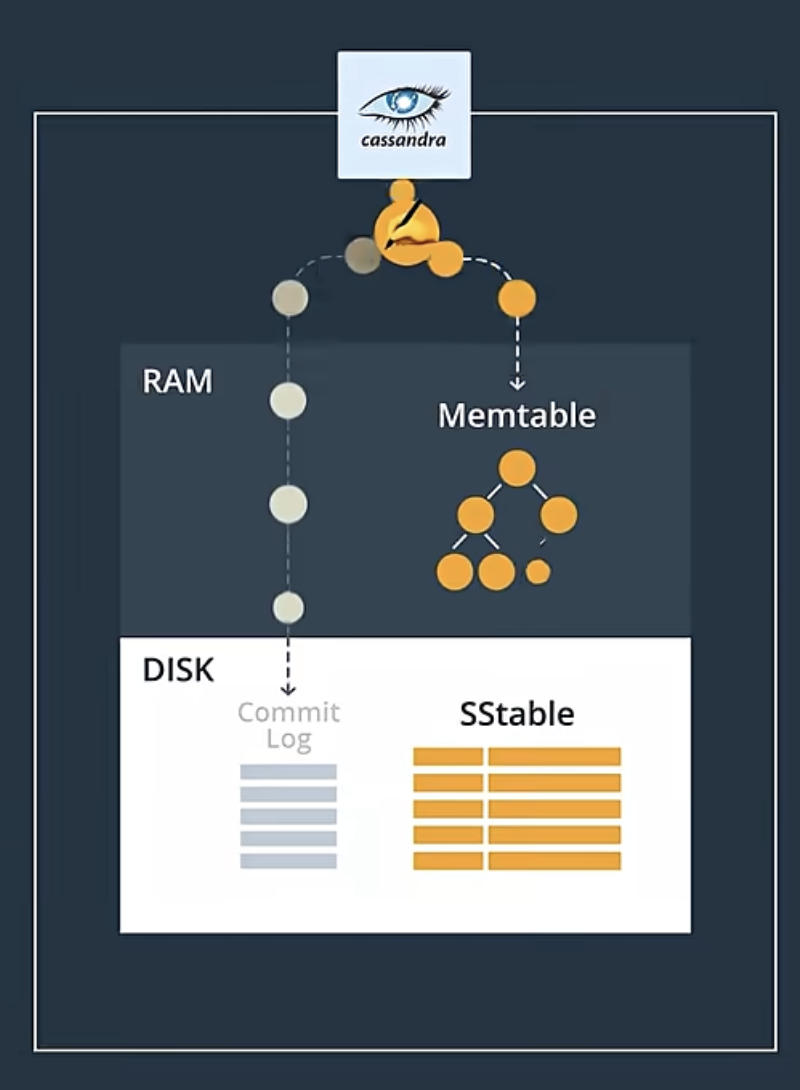